# Exercício guiado: engenharia e seleção de atributos no Olist

M05, Processamento e Visualização de Dados.

Nesta atividade você percorre, sozinho, o caminho das duas aulas do módulo: partir de uma pergunta de negócio, cruzar as tabelas do Olist, construir atributos a partir de hipóteses, escolher um subconjunto deles e medir o resultado com um modelo fixo.

O notebook segue as três camadas da aula:

| camada | o que é | onde está neste notebook |
|---|---|---|
| **bronze** | os 9 CSV como vieram da fonte | seção 1 |
| **silver** | uma linha por pedido, tabelas cruzadas, tipos certos; nada construído a partir de uma hipótese, nenhum alvo | seção 3 |
| **gold** | a silver mais o alvo e os atributos construídos a partir de hipóteses | seção 4 |

**O que está pronto e o que é seu**

- Pronto, em `suite_exercicio.py`: download dos dados, os blocos que cruzam as tabelas, o split por data, os métodos de seleção, o modelo e a métrica. Os joins da silver vêm feitos, com cada passo explicado.
- Seu: definir o alvo, propor e construir atributos, listar as candidatas, escolher pelo menos três métodos de seleção, comparar e concluir.

**Como usar este notebook**

1. Rode as células na ordem. As que começam com `# SUA VEZ` esperam código seu; os trechos "**Sua resposta:**" esperam texto.
2. Leia a docstring de cada função da suite antes de usá-la: `help(su.nome_da_funcao)`. Ela diz o que entra, o que sai e o que a função esconde.
3. Tempo de computação: até 5 minutos no Colab gratuito, menos de um minuto numa máquina com vários núcleos. A seleção sequencial não imprime nada até terminar.

**Entrega:** este notebook executado e a pasta `resultados/` que ele grava na seção 7.

## 1. Preparação do ambiente (bronze)

O que se espera desta seção: o notebook encontra a suite, baixa os nove CSV do Olist e os carrega em memória. Nada para escrever aqui.

No Colab, envie `suite_exercicio.py` quando a célula pedir, ou arraste o arquivo para a aba de arquivos, à esquerda.

Primeiro, os pacotes. No Colab eles já vêm instalados, e a célula abaixo só confirma as versões mínimas (leva alguns segundos; o aviso sobre reiniciar o kernel só importa se algo foi instalado). Fora do Colab, rode a mesma linha no seu ambiente, ou `pip install -r requirements.txt`.

In [1]:
%pip install -q "pandas>=2.2" "numpy>=1.26" "scikit-learn>=1.4" "matplotlib>=3.8"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

if not Path("suite_exercicio.py").exists():
    try:
        from google.colab import files
        print("Envie o arquivo suite_exercicio.py")
        files.upload()
    except ImportError:
        raise FileNotFoundError("coloque suite_exercicio.py na mesma pasta deste notebook")

In [3]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import suite_exercicio as su

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

O download usa o endpoint público do Kaggle (cerca de 45 MB) e não pede conta. Se falhar, baixe o zip pelo navegador em `kaggle.com/datasets/olistbr/brazilian-ecommerce`, envie para a sessão e rode `su.extrair_zip("archive.zip")` antes de continuar.

In [4]:
bronze = su.carregar_bronze()   # baixa, descompacta e le os 9 CSV

for nome, conteudo in bronze.items():
    print(f"{nome:<15} {len(conteudo):>9,} linhas x {conteudo.shape[1]:>2} colunas")

os 9 CSV ja estao em dados_olist/


pedidos            99,441 linhas x  8 colunas
itens             112,650 linhas x  7 colunas
pagamentos        103,886 linhas x  5 colunas
avaliacoes         99,224 linhas x  7 colunas
clientes           99,441 linhas x  5 colunas
vendedores          3,095 linhas x  4 colunas
produtos           32,951 linhas x  9 colunas
geolocalizacao  1,000,163 linhas x  5 colunas
traducao               71 linhas x  2 colunas


Bronze é isto: nove tabelas, cada uma no grão em que a fonte a gravou (uma linha por item, por pagamento, por coordenada de CEP). Nenhuma regra de negócio foi aplicada; só as colunas de data já vêm convertidas.

## 2. A pergunta de negócio

O que se espera desta seção: entender a decisão, o momento em que ela é tomada e a métrica, e responder à pergunta escrita no fim.

O Olist é um marketplace: quem vende é o lojista, quem entrega é a transportadora. No checkout, o cliente vê uma data estimada de entrega, em geral conservadora. Um selo de "entrega rápida" ao lado do produto vende mais, mas só se for verdade: prometer rápido e entregar devagar custa a avaliação.

**A pergunta:** no momento da compra, este pedido vai chegar em até 10 dias?

- **Decisão:** o site decide se mostra o selo de entrega rápida para este pedido. Errar para mais frustra o cliente; errar para menos perde venda.
- **Momento da decisão:** a compra (`order_purchase_timestamp`). Só entra no modelo o que já existe nesse instante: quem compra, de quem, o quê, por quanto, como paga e qual prazo foi prometido.
- **Alvo:** binário. 1 se o pedido foi entregue em até 10 dias depois da compra, 0 caso contrário.
- **Métrica oficial: acurácia**, com limiar 0,5. É a fração de pedidos do teste em que o modelo acertou se a entrega seria rápida ou não. A referência mínima é a classe majoritária: um modelo que diz sempre "rápida" acerta a fração de pedidos rápidos, e qualquer conjunto de colunas precisa passar disso. O teste é o período a partir de 2018-03-01. Todo mundo mede o mesmo modelo, no mesmo teste, com a mesma métrica.

A pergunta é parecida com a das aulas, com uma troca: lá, o tempo de entrega era vazamento e a nota era o alvo; aqui, o tempo de entrega é o alvo e a nota é vazamento.

(a) liste quais das nove tabelas você espera precisar, e para quê, e diga qual fica de fora e por quê; (b) cite duas colunas que existem na base e que seriam vazamento para esta pergunta.

**Resposta:**

(a) `pedidos` (datas de compra e de entrega, que definem o alvo, e o prazo prometido), `clientes` (destino: estado e CEP), `itens` (o que foi comprado, preço e frete), `produtos` e `traducao` (peso, dimensões e categoria), `vendedores` (origem: estado e CEP do lojista), `geolocalizacao` (coordenadas para a distância entre origem e destino) e `pagamentos` (tipo e parcelas). A tabela `avaliacoes` não entra: a avaliação é escrita depois da entrega.

(b) `order_delivered_customer_date` (é a data que define o alvo), `order_delivered_carrier_date` (a postagem acontece depois da compra), `order_approved_at` (a aprovação vem depois da compra) e `review_score`.

## 3. Bronze para silver: uma linha por pedido

O que se espera desta seção: entender cada cruzamento. Os joins vêm prontos; o que importa é o porquê de cada passo, porque é aqui que um pedido vira dois sem ninguém perceber. Nada para escrever.

Toda função de bloco da suite devolve uma tabela **indexada por `order_id`**, pronta para `silver.join(bloco)`. Depois de cada join, conferimos que o número de linhas não mudou.

**Passo 1: a base.** Só pedidos entregues e com data de entrega (sem ela não existe o alvo). O cliente entra por um join 1:1, porque cada pedido tem o seu `customer_id`.

In [5]:
silver = su.montar_base(bronze)
n_pedidos = len(silver)

print(f"{n_pedidos:,} pedidos entregues, de {len(bronze['pedidos']):,} na tabela original")
silver[["order_purchase_timestamp", "order_estimated_delivery_date", "customer_state", "customer_zip_code_prefix"]].head(3)

96,470 pedidos entregues, de 99,441 na tabela original


,order_purchase_timestamp,order_estimated_delivery_date,customer_state,customer_zip_code_prefix
order_id,,,,
e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,SP,3149
53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,BA,47813
47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,GO,75265


**Passo 2: os itens.** A tabela de itens tem uma linha por item, e um pedido pode ter vários. Juntar como está multiplicaria o pedido pelo número de itens; por isso a tabela é **agregada antes** do join: contagem de itens, de produtos e de lojistas, soma do valor e do frete, preço do item mais caro.

In [6]:
itens_por_pedido = su.agregar_itens_por_pedido(bronze["itens"])
print(f"{len(bronze['itens']):,} linhas de item viram {len(itens_por_pedido):,} linhas de pedido")

silver = silver.join(itens_por_pedido, how="inner")
assert len(silver) == n_pedidos

silver[["n_itens", "n_produtos", "n_vendedores", "valor_total", "frete_total", "preco_maximo"]].head(3)

112,650 linhas de item viram 98,666 linhas de pedido


,n_itens,n_produtos,n_vendedores,valor_total,frete_total,preco_maximo
order_id,,,,,,
e481f51cbdc54678b7cc49136f2d6af7,1,1,1,29.99,8.72,29.99
53cdb2fc8bc7dce0b6741e2150273451,1,1,1,118.70,22.76,118.70
47770eb9100c2d0c44946d9cf07ec65d,1,1,1,159.90,19.22,159.90


**Passo 3: o produto.** "O produto do pedido" exige uma escolha quando há mais de um: a suite usa o item mais caro. Da tabela de produtos vêm peso, dimensões, fotos, tamanho da descrição e a categoria, traduzida pela tabela de tradução (os 610 produtos sem categoria viram `desconhecida`).

In [7]:
silver = silver.join(su.atributos_do_produto(bronze["itens"], bronze["produtos"], bronze["traducao"]))
assert len(silver) == n_pedidos

silver[["categoria", "peso_g", "comprimento_cm", "altura_cm", "largura_cm", "n_fotos"]].head(3)

,categoria,peso_g,comprimento_cm,altura_cm,largura_cm,n_fotos
order_id,,,,,,
e481f51cbdc54678b7cc49136f2d6af7,housewares,500.0,19.0,8.0,13.0,4.0
53cdb2fc8bc7dce0b6741e2150273451,perfumery,400.0,19.0,13.0,19.0,1.0
47770eb9100c2d0c44946d9cf07ec65d,auto,420.0,24.0,19.0,21.0,1.0


**Passo 4: o lojista.** No dado ele é o `seller`, e nas funções da suite, `vendedor`; no texto, lojista. Mesma escolha (o do item mais caro), e da tabela de vendedores vêm o CEP e o estado de origem.

In [8]:
silver = silver.join(su.atributos_do_vendedor(bronze["itens"], bronze["vendedores"]))
assert len(silver) == n_pedidos

silver[["seller_id", "seller_state", "seller_zip_code_prefix"]].head(3)

,seller_id,seller_state,seller_zip_code_prefix
order_id,,,
e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,SP,9350
53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,SP,31570
47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,SP,14840


**Passo 5: o pagamento.** Cerca de 3% dos pedidos têm mais de um pagamento (um voucher e um cartão, por exemplo). A suite fica com o tipo do pagamento de maior valor e o maior número de parcelas.

In [9]:
silver = silver.join(su.resumo_pagamentos(bronze["pagamentos"]))
assert len(silver) == n_pedidos

silver[["tipo_pagamento", "n_parcelas", "n_pagamentos", "valor_pago"]].head(3)

,tipo_pagamento,n_parcelas,n_pagamentos,valor_pago
order_id,,,,
e481f51cbdc54678b7cc49136f2d6af7,voucher,1.0,3.0,38.71
53cdb2fc8bc7dce0b6741e2150273451,boleto,1.0,1.0,141.46
47770eb9100c2d0c44946d9cf07ec65d,credit_card,3.0,1.0,179.12


**Passo 6: a distância.** A tabela de geolocalização tem um milhão de linhas, várias por prefixo de CEP. Juntá-la direto à base multiplicaria cada pedido por dezenas. A suite colapsa a tabela para **uma coordenada mediana por prefixo**, só então busca a coordenada do cliente e a do lojista, e calcula a distância em linha reta.

In [10]:
silver["distancia_km"] = su.distancia_cliente_vendedor(silver, bronze["geolocalizacao"])
assert len(silver) == n_pedidos

silver[["customer_state", "seller_state", "distancia_km"]].head(3)

,customer_state,seller_state,distancia_km
order_id,,,
e481f51cbdc54678b7cc49136f2d6af7,SP,SP,18.681711
53cdb2fc8bc7dce0b6741e2150273451,BA,SP,861.035367
47770eb9100c2d0c44946d9cf07ec65d,GO,SP,514.547140


**Silver pronta.** Uma linha por pedido, oito tabelas cruzadas (a nona, avaliações, fica de fora por vazamento), tipos certos. As únicas colunas novas são as que nascem dos próprios joins (as agregações por pedido e a distância); nenhuma foi construída a partir de uma hipótese, e o alvo não existe. Na aula, esta tabela foi gravada em parquet; aqui ela fica em memória.

In [11]:
print(f"silver: {silver.shape[0]:,} linhas x {silver.shape[1]} colunas")
print(f"valores ausentes em distancia_km: {silver['distancia_km'].isna().sum()}, em peso_g: {silver['peso_g'].isna().sum()}")
print()
print("colunas:", ", ".join(silver.columns))

silver: 96,470 linhas x 33 colunas
valores ausentes em distancia_km: 476, em peso_g: 16

colunas: customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state, n_itens, n_produtos, n_vendedores, valor_total, frete_total, preco_maximo, peso_g, comprimento_cm, altura_cm, largura_cm, n_fotos, tamanho_descricao, categoria, seller_id, seller_zip_code_prefix, seller_city, seller_state, n_pagamentos, n_parcelas, valor_pago, tipo_pagamento, distancia_km


## 4. Silver para gold: o alvo e os atributos

O que se espera desta seção: a gold nasce como uma cópia da silver e cresce com o alvo (4.1) e com colunas construídas a partir de hipóteses sobre o negócio (4.2); no fim, a lista de candidatas passa pela checagem de vazamento (4.3).

### 4.1 O alvo

Crie a coluna `entrega_rapida`: 1 quando o pedido foi entregue em até 10 dias depois da compra, 0 caso contrário. Subtrair duas colunas de data dá uma duração; `.dt.days` a converte em dias inteiros; a comparação devolve uma Series booleana; `.astype(int)` a transforma em 0/1.

Convenção, para que todos fiquem na mesma base: dias completos (`.dt.days` descarta as horas, então quem chegou com 10 dias e 20 horas conta como rápido) e comparação com `<= 10`. `su.conferir_alvo` confere o formato e avisa se a taxa fugir da esperada.

In [12]:
gold = silver.copy()

tempo_entrega_dias = (gold["order_delivered_customer_date"] - gold["order_purchase_timestamp"]).dt.days
gold["entrega_rapida"] = (tempo_entrega_dias <= 10).astype(int)

su.conferir_alvo(gold, "entrega_rapida", taxa_esperada=0.54)

entrega_rapida: 54.0% de positivos em 96,470 pedidos


0.5400124391002384

A taxa não é constante no tempo. O gráfico abaixo é o motivo de o split, mais adiante, ser por data e não aleatório: o modelo vai ser usado no futuro, e o futuro tem taxa diferente do passado. A linha tracejada marca o início do teste.

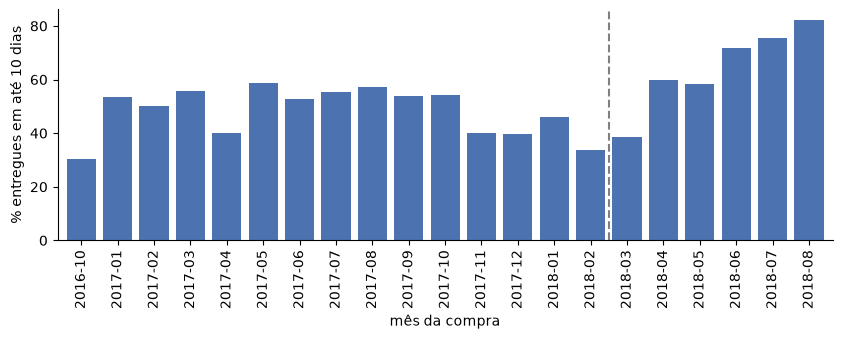

In [13]:
ALVO = "entrega_rapida"

por_mes = gold.groupby(gold["order_purchase_timestamp"].dt.strftime("%Y-%m"))[ALVO].agg(["size", "mean"])
por_mes = por_mes[por_mes["size"] > 100]

ax = (100 * por_mes["mean"]).plot(kind="bar", figsize=(10, 3), color="#4C72B0", width=0.8)
ax.axvline(list(por_mes.index).index("2018-03") - 0.5, color="gray", linestyle="--")
ax.set_ylabel("% entregues em até 10 dias")
ax.set_xlabel("mês da compra")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Dois avisos de leitura. A subida de abril a agosto de 2018 é tendência: a malha ficou mais rápida, e o modelo treinado no passado vai encontrar um futuro diferente. E o último mês tem um viés pequeno: os 77 pedidos de agosto de 2018 ainda a caminho quando a base foi extraída não aparecem como entregues (cerca de 1% do mês; a barra seria um ponto menor).

### 4.2 Hipóteses e atributos

Um atributo nasce de uma hipótese sobre o que faz a entrega demorar. O padrão de cada hipótese é o mesmo das aulas: uma frase, o código que constrói a coluna e a evidência de que ela separa (`su.taxa_por_faixa`).

As três primeiras estão feitas, para mostrar o padrão. Escreva pelo menos **três** outras, em direções diferentes. Sugestões de direção, sem código: peso e volume do produto; frete, absoluto ou em relação ao valor; calendário da compra (mês, dia da semana, hora); tamanho do pedido (itens, lojistas); região do cliente ou do lojista (o dicionário `su.REGIAO_POR_ESTADO` leva a UF à região; com `.map()` e `su.dummies` vira colunas 0/1); razões entre colunas. Uma hipótese que não separa também é resultado: registre e siga.

Três regras. Data não entra no modelo: vira número (dias entre datas, hora, dia da semana). Texto também não: vira 0/1 com `su.dummies`. E para escolher os cortes de `su.taxa_por_faixa`, olhe antes os quantis da coluna (`gold[coluna].describe()`).

A evidência por faixa é descritiva e usa a base inteira, inclusive o período que vai virar teste. A seleção de atributos, na seção 6, usa só o treino.

**H1. Distância.** Quanto mais longe o lojista do cliente, mais tempo a transportadora leva. A coluna `distancia_km` já veio da silver; aqui entra a versão mais simples da mesma ideia, `mesmo_estado`, e a evidência das duas.

In [14]:
gold["mesmo_estado"] = (gold["customer_state"] == gold["seller_state"]).astype(int)

print(su.taxa_por_faixa(gold, "mesmo_estado", ALVO))
su.taxa_por_faixa(gold, "distancia_km", ALVO, cortes=[0, 100, 300, 1000, 5000],
                  rotulos=["até 100 km", "100 a 300 km", "300 a 1.000 km", "mais de 1.000 km"])

                  n  taxa
mesmo_estado             
0             61780  39.2
1             34690  80.4


,n,taxa
distancia_km,,
até 100 km,17891,87.7
100 a 300 km,13357,68.9
300 a 1.000 km,49403,48.6
mais de 1.000 km,15340,19.5


**H2. Prazo prometido.** A data estimada é mostrada no checkout, então é conhecida na compra. O Olist calcula essa data a partir da rota; um prazo longo é o próprio sistema dizendo que a entrega vai demorar.

In [15]:
gold["prazo_prometido_dias"] = (gold["order_estimated_delivery_date"] - gold["order_purchase_timestamp"]).dt.days

su.taxa_por_faixa(gold, "prazo_prometido_dias", ALVO, cortes=[0, 15, 20, 25, 30, 200],
                  rotulos=["até 15 dias", "15 a 20", "20 a 25", "25 a 30", "mais de 30"])

,n,taxa
prazo_prometido_dias,,
até 15 dias,16626,91.2
15 a 20,18680,66.7
20 a 25,26437,50.7
25 a 30,17674,37.1
mais de 30,17053,26.4


**H3. Forma de pagamento.** Boleto leva um ou dois dias para compensar, e o lojista só despacha depois da aprovação. O tipo de pagamento é texto; `su.dummies` o transforma em colunas 0/1.

In [16]:
print(su.taxa_por_faixa(gold, "tipo_pagamento", ALVO))

gold = gold.join(su.dummies(gold, "tipo_pagamento", minimo=500, prefixo="pag"))
[coluna for coluna in gold.columns if coluna.startswith("pag_")]

                    n  taxa
tipo_pagamento             
boleto          19191  47.4
credit_card     72818  55.6
debit_card       1483  64.0
voucher          2977  53.5


['pag_boleto',
 'pag_credit_card',
 'pag_debit_card',
 'pag_outros',
 'pag_voucher']

**H4. Peso e volume.** Pacote grande ou pesado vai por outro fluxo na transportadora. O volume não vem pronto: é o produto das três dimensões.

In [17]:
gold["volume_cm3"] = gold["comprimento_cm"] * gold["altura_cm"] * gold["largura_cm"]

print(su.taxa_por_faixa(gold, "peso_g", ALVO, cortes=[0, 500, 2000, 10000, 100000],
                        rotulos=["até 500 g", "500 g a 2 kg", "2 a 10 kg", "mais de 10 kg"]))
su.taxa_por_faixa(gold, "volume_cm3", ALVO, cortes=[0, 2000, 10000, 50000, 1e7],
                  rotulos=["até 2 L", "2 a 10 L", "10 a 50 L", "mais de 50 L"])

                   n  taxa
peso_g                    
até 500 g      40767  57.2
500 g a 2 kg   33575  53.3
2 a 10 kg      17597  50.8
mais de 10 kg   4515  43.0


,n,taxa
volume_cm3,,
até 2 L,15205,59.7
2 a 10 L,44520,54.4
10 a 50 L,30387,52.3
mais de 50 L,6342,45.4


**H5. Frete.** O frete é calculado pela transportadora a partir da rota e do pacote, então resume distância e tamanho. Em relação ao valor do produto, ele também diz algo sobre o tipo de compra.

In [18]:
gold["frete_relativo"] = gold["frete_total"] / gold["valor_total"]

print(su.taxa_por_faixa(gold, "frete_total", ALVO, cortes=[0, 10, 15, 25, 50, 1000],
                        rotulos=["até R$10", "10 a 15", "15 a 25", "25 a 50", "mais de 50"]))
su.taxa_por_faixa(gold, "frete_relativo", ALVO, cortes=[0, 0.1, 0.2, 0.4, 100],
                  rotulos=["até 10%", "10 a 20%", "20 a 40%", "mais de 40%"])

                 n  taxa
frete_total             
até R$10     11073  89.9
10 a 15      19534  69.2
15 a 25      42811  46.0
25 a 50      16981  39.9
mais de 50    6069  35.3


,n,taxa
frete_relativo,,
até 10%,15257,60.5
10 a 20%,27684,57.2
20 a 40%,31365,52.6
mais de 40%,22164,47.4


**H6. Calendário.** Compra no fim de semana espera a segunda-feira; novembro e dezembro têm Black Friday e Natal; a hora da compra decide se o pedido entra no despacho do mesmo dia. O mês cruzado com o ano separa o que é calendário (repete nos dois anos) do que é tendência (só em 2018).

In [19]:
compra = gold["order_purchase_timestamp"]
gold["mes"] = compra.dt.month
gold["dia_da_semana"] = compra.dt.dayofweek
gold["hora"] = compra.dt.hour
gold["fim_de_semana"] = gold["dia_da_semana"].isin([5, 6]).astype(int)

print(su.taxa_por_faixa(gold, "fim_de_semana", ALVO))
print(su.taxa_por_faixa(gold, "hora", ALVO, cortes=[0, 5, 11, 17, 23],
                        rotulos=["madrugada", "manhã", "tarde", "noite"]))

por_mes_e_ano = gold.assign(ano=compra.dt.year).pivot_table(index="mes", columns="ano", values=ALVO, aggfunc="mean")
(100 * por_mes_e_ano[[2017, 2018]]).round(1)

                   n  taxa
fim_de_semana             
0              74283  53.7
1              22187  55.1
               n  taxa
hora                  
madrugada   4594  53.1
manhã      21593  54.1
tarde      37179  53.2
noite      33104  54.9


ano,2017,2018
mes,,
1,53.6,46.2
2,50.2,33.5
3,55.7,38.7
4,40.0,60.0
5,58.6,58.2
6,52.6,71.9
7,55.2,75.6
8,57.3,82.1
9,53.7,NaN


**H7. Tamanho do pedido.** Mais itens, ou itens de lojistas diferentes, e o pedido espera o último pacote. As colunas já vieram da silver; aqui só a evidência.

In [20]:
print(su.taxa_por_faixa(gold, "n_itens", ALVO, cortes=[0, 1, 2, 100], rotulos=["1", "2", "3 ou mais"]))
su.taxa_por_faixa(gold, "n_vendedores", ALVO)

               n  taxa
n_itens               
1          86835  53.7
2           7392  56.8
3 ou mais   2243  56.6


,n,taxa
n_vendedores,,
1,95195,53.8
2,1216,70.9
3,54,81.5
4,3,33.3
5,2,50.0


**H8. Região.** A malha de transporte é desigual: o Sudeste é servido melhor que o Norte, e a maior parte dos lojistas está em São Paulo.

In [21]:
gold["regiao_cliente"] = gold["customer_state"].map(su.REGIAO_POR_ESTADO)
gold = gold.join(su.dummies(gold, "regiao_cliente", minimo=1))
gold["vendedor_sp"] = (gold["seller_state"] == "SP").astype(int)

print(su.taxa_por_faixa(gold, "regiao_cliente", ALVO).sort_values("taxa"))
su.taxa_por_faixa(gold, "vendedor_sp", ALVO)

                    n  taxa
regiao_cliente             
norte            1796  10.0
nordeste         9044  16.0
centro_oeste     5624  33.5
sul             13813  42.3
sudeste         66193  64.6


,n,taxa
vendedor_sp,,
0,28084,50.3
1,68386,55.5


### 4.3 A lista de candidatas e a checagem de vazamento

Liste as colunas que podem entrar no modelo: só as numéricas, nada que nasça depois da compra. `su.checar_atributos` barra o que não pode e devolve a lista se estiver tudo certo. As colunas de H1 a H3 já estão no esqueleto; acrescente as suas e as numéricas que já vieram da silver.

Dois cuidados. A barreira de `su.checar_atributos` é por nome: uma coluna calculada a partir de uma coluna do futuro (o tempo até a postagem, por exemplo) passa sem aviso, então, para cada coluna sua, saiba de quais colunas brutas ela vem. E ao pegar as colunas de `su.dummies` por prefixo, lembre que a coluna de texto original pode começar com o mesmo prefixo; `list(su.dummies(...).columns)` evita a confusão.

In [22]:
candidatas = [
    # tamanho e valor do pedido (silver, bloco de itens)
    "n_itens", "n_produtos", "n_vendedores", "valor_total", "frete_total", "preco_maximo",
    # produto (silver, bloco de produtos) e H4
    "peso_g", "comprimento_cm", "altura_cm", "largura_cm", "n_fotos", "tamanho_descricao", "volume_cm3",
    # pagamento (silver) e H3
    "n_parcelas", "n_pagamentos", "valor_pago",
    # H1, H2, H5, H6, H8
    "distancia_km", "mesmo_estado", "prazo_prometido_dias", "frete_relativo",
    "mes", "dia_da_semana", "hora", "fim_de_semana", "vendedor_sp",
]
candidatas += [coluna for coluna in gold.columns if coluna.startswith(("pag_", "regiao_cliente_"))]

candidatas = su.checar_atributos(gold, candidatas, ALVO)
print(len(candidatas), "candidatas")

35 candidatas


Veja o que acontece ao tentar incluir a data de aprovação do pagamento:

In [23]:
try:
    su.checar_atributos(gold, candidatas + ["order_approved_at"], ALVO)
except ValueError as erro:
    print("barrado:", erro)

barrado: colunas que so existem depois da decisao (vazamento): ['order_approved_at']


**Resposta:** o selo é decidido no instante da compra, e nesse instante a aprovação ainda não aconteceu: um modelo que dependesse dela não teria o valor na hora de prever. A distância no tempo não importa; importa que a coluna está à direita do momento da decisão. E ela carregaria informação de verdade: o tempo até a aprovação revela se o pagamento foi boleto (dias) ou cartão (minutos), e isso já se reflete no tempo de entrega. O que é legítimo usar é o tipo de pagamento, que o cliente escolhe antes de fechar a compra (H3).

**Gold pronta:** a silver mais o alvo e as candidatas. Daqui em diante só se usa `gold`, e só as colunas de `candidatas`.

## 5. Split por data e ponto de partida

O que se espera desta seção: treino com as compras antes de 2018-03-01, teste com as compras a partir dele, e a primeira medição, com todas as candidatas, que serve de referência. Nada para escrever.

`su.dividir_por_data` faz a checagem de vazamento, o corte e a imputação (mediana calculada só no treino). `su.avaliar` ajusta a floresta de referência e mede a acurácia no teste. O modelo é fixo: o exercício compara conjuntos de colunas, não modelos.

In [24]:
dados = su.dividir_por_data(gold, candidatas, ALVO)
su.resumo_do_split(dados)

,linhas,positivos,taxa_%
treino,57317,27134,47.3
teste,39153,24961,63.8


In [25]:
print(f"acurácia da maioria (sem modelo): {su.acuracia_da_maioria(dados):.3f}")

referencia = su.avaliar(candidatas, dados)
referencia

acurácia da maioria (sem modelo): 0.638


{'n_colunas': 35, 'acuracia': 0.716}

Guarde esses dois números. A maioria é o chão: qualquer conjunto de colunas precisa passar dela. A referência com todas as candidatas é o teto atual: cada método de seleção vai ser julgado contra ela. Menos colunas com a mesma acurácia é ganho; acurácia menor é o preço de ter menos colunas, e alguém precisa decidir se vale. Com cerca de 39 mil pedidos no teste, o erro padrão da acurácia é de um quarto de ponto percentual: diferenças dessa ordem são ruído.

## 6. Seleção de atributos

O que se espera desta seção: pelo menos três métodos, de famílias diferentes, cada um devolvendo uma lista de colunas. Todos usam só o treino (`dados.X_treino`, `dados.y_treino`); o teste fica para a comparação final.

O que a suite oferece:

| família | função | custo | observação |
|---|---|---|---|
| filtro | `su.podar_por_correlacao(X)` | um cálculo | não usa o alvo; devolve `(mantidas, pares)` |
| filtro | `su.selecionar_por_f_classif(X, y, k)` | um cálculo | univariado; `su.ranking_f_classif` devolve a Series inteira |
| wrapper | `su.selecionar_sequencial(X, y, k)` | o mais caro; não imprime nada até terminar | forward, acurácia em validação cruzada, sobre uma amostra do treino |
| embedded | `su.selecionar_por_importancia(X, y, k)` | um ajuste | `feature_importances_`; `su.ranking_impureza` devolve a Series |
| embedded | `su.ranking_permutacao(X, y)` | um ajuste e muitas predições | queda de acurácia numa validação sorteada dentro do treino; devolve só a Series, sem função de corte |
| embedded | `su.selecionar_por_modelo(X, y, limiar)` | um ajuste | `SelectFromModel`; é o que entra num `Pipeline` |

O padrão de uso é o mesmo em todos: `escolha = su.selecionar_por_f_classif(X_treino, y_treino, k=10)` devolve uma lista de nomes de colunas; quem devolve uma Series (os `ranking_*`) vira lista com `list(ranking.head(k).index)`. Os parâmetros padrão (`k=10`, `k=8`, `limiar="median"`) são um ponto de partida, não uma regra.

Combinar é permitido (podar por correlação e depois rankear, por exemplo), desde que o conjunto final de cada método esteja em `conjuntos`.

In [26]:
X_treino, y_treino = dados.X_treino, dados.y_treino

# Metodo 1, filtro: a estatistica F de cada coluna contra o alvo, as 10 maiores.
ranking_F = su.ranking_f_classif(X_treino, y_treino)
escolha_filtro = list(ranking_F.head(10).index)

ranking_F.head(15).round(1)

mesmo_estado                   11070.5
distancia_km                   10184.9
prazo_prometido_dias            9948.1
regiao_cliente_sudeste          6448.9
regiao_cliente_nordeste         3283.3
frete_total                     1871.5
regiao_cliente_norte             737.6
regiao_cliente_sul               697.7
regiao_cliente_centro_oeste      648.1
frete_relativo                   535.3
pag_boleto                       249.7
peso_g                           235.6
valor_pago                       219.0
comprimento_cm                   215.8
pag_credit_card                  182.9
dtype: float64

In [27]:
# Metodo 2, wrapper: forward selection guiada pela acuracia, ate 8 colunas.
escolha_wrapper = su.selecionar_sequencial(X_treino, y_treino, k=8)

escolha_wrapper

SequentialFeatureSelector: 8 colunas em 20 s


['altura_cm',
 'mesmo_estado',
 'prazo_prometido_dias',
 'mes',
 'fim_de_semana',
 'pag_outros',
 'regiao_cliente_centro_oeste',
 'regiao_cliente_nordeste']

O wrapper roda sobre uma amostra de 8.000 linhas. Rodar de novo com outra amostra mostra quanto da escolha é sinal e quanto é ruído.

In [28]:
outra_amostra = su.selecionar_sequencial(X_treino, y_treino, k=8, random_state=1)

print("so na primeira rodada:", sorted(set(escolha_wrapper) - set(outra_amostra)))
print("so na segunda rodada: ", sorted(set(outra_amostra) - set(escolha_wrapper)))
print("nas duas:             ", sorted(set(escolha_wrapper) & set(outra_amostra)))

SequentialFeatureSelector: 8 colunas em 14 s
so na primeira rodada: ['altura_cm', 'fim_de_semana', 'pag_outros']
so na segunda rodada:  ['dia_da_semana', 'distancia_km', 'regiao_cliente_sudeste']
nas duas:              ['mes', 'mesmo_estado', 'prazo_prometido_dias', 'regiao_cliente_centro_oeste', 'regiao_cliente_nordeste']


In [29]:
# Metodo 3, embedded: SelectFromModel, com a mediana das importancias como limiar.
escolha_embedded = su.selecionar_por_modelo(X_treino, y_treino, limiar="median")

print(len(escolha_embedded), "colunas")
escolha_embedded

18 colunas


['valor_total',
 'frete_total',
 'preco_maximo',
 'peso_g',
 'comprimento_cm',
 'altura_cm',
 'largura_cm',
 'tamanho_descricao',
 'volume_cm3',
 'valor_pago',
 'distancia_km',
 'mesmo_estado',
 'prazo_prometido_dias',
 'frete_relativo',
 'mes',
 'dia_da_semana',
 'regiao_cliente_nordeste',
 'regiao_cliente_sudeste']

In [30]:
# Um conjunto a mais, que nao e metodo: as colunas em que os tres concordaram.
escolhas_dos_tres = [escolha_filtro, escolha_wrapper, escolha_embedded]
nucleo = [coluna for coluna in candidatas if all(coluna in escolha for escolha in escolhas_dos_tres)]
print("nucleo:", nucleo)

conjuntos = {
    "todas": candidatas,
    "filtro: f_classif top 10": escolha_filtro,
    "wrapper: SFS 8": escolha_wrapper,
    "embedded: SelectFromModel": escolha_embedded,
    "nucleo: escolhidas pelos 3": nucleo,
}

nucleo: ['mesmo_estado', 'prazo_prometido_dias', 'regiao_cliente_nordeste']


## 7. Modelagem e comparação

O que se espera desta seção: a mesma floresta, o mesmo teste, a mesma métrica para cada conjunto. Nada para escrever; leia a tabela, o gráfico e a matriz de escolhas.

In [31]:
tabela = su.comparar(conjuntos, dados)
tabela

maioria (sem modelo)                acuracia 0.638


todas                           35 colunas  acuracia 0.716


filtro: f_classif top 10        10 colunas  acuracia 0.697


wrapper: SFS 8                   8 colunas  acuracia 0.704


embedded: SelectFromModel       18 colunas  acuracia 0.717


nucleo: escolhidas pelos 3       3 colunas  acuracia 0.698


,n_colunas,acuracia,segundos
todas,35,0.716,1.6
filtro: f_classif top 10,10,0.697,1.0
wrapper: SFS 8,8,0.704,0.6
embedded: SelectFromModel,18,0.717,1.8
nucleo: escolhidas pelos 3,3,0.698,0.4


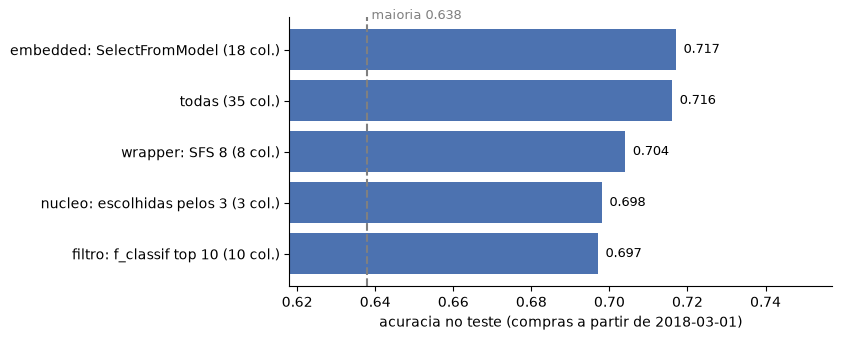

In [32]:
su.grafico_comparacao(tabela, dados)
plt.show()

O eixo do gráfico começa perto da maioria, não em zero: as diferenças entre barras são de poucos pontos percentuais.

A matriz de escolhas mostra em que colunas os métodos concordam. `total` é o número de métodos que escolheram a coluna.

In [33]:
metodos = {nome: colunas for nome, colunas in conjuntos.items() if nome != "todas" and not nome.startswith("nucleo")}
escolhas = su.matriz_de_escolhas(metodos, candidatas)
escolhas[escolhas["total"] > 0]

,filtro: f_classif top 10,wrapper: SFS 8,embedded: SelectFromModel,total
mesmo_estado,1,1,1,3
regiao_cliente_nordeste,1,1,1,3
prazo_prometido_dias,1,1,1,3
regiao_cliente_sudeste,1,0,1,2
frete_total,1,0,1,2
regiao_cliente_centro_oeste,1,1,0,2
altura_cm,0,1,1,2
mes,0,1,1,2
frete_relativo,1,0,1,2
distancia_km,1,0,1,2


### 7.1 Salvar os resultados

A célula grava a tabela, a matriz, as listas de colunas e o gráfico em `resultados/`. No Colab, baixe a pasta pela aba de arquivos (ou compacte com `!zip -r resultados.zip resultados`).

In [34]:
saida = Path("resultados")
saida.mkdir(exist_ok=True)

tabela.to_csv(saida / "comparacao.csv")
escolhas.to_csv(saida / "matriz_de_escolhas.csv")
with open(saida / "colunas_escolhidas.json", "w", encoding="utf-8") as arquivo:
    json.dump({nome: list(colunas) for nome, colunas in conjuntos.items()}, arquivo, indent=2, ensure_ascii=False)
su.grafico_comparacao(tabela, dados).figure.savefig(saida / "comparacao.png", dpi=150, bbox_inches="tight")
plt.close()

sorted(caminho.name for caminho in saida.iterdir())

['colunas_escolhidas.json',
 'comparacao.csv',
 'comparacao.png',
 'matriz_de_escolhas.csv']

## 8. Conclusões

**1. Qual conjunto iria para produção.** O `SelectFromModel` (18 colunas, acurácia 0,717) empata com as 35 candidatas (0,716) com metade das colunas: é a escolha se a acurácia manda. O wrapper (8 colunas, 0,704) custa 1,2 pontos e dispensa `distancia_km`, a coluna mais cara de manter (exige o join com a geolocalização a cada pedido). O núcleo de 3 colunas em que os três métodos concordaram (0,698) faz três quartos do ganho sobre a maioria (0,638 para 0,716) com colunas que já existem no pedido: mesmo estado, região do cliente e prazo prometido. Para colocar um selo no checkout amanhã, o núcleo; se dois pontos de acurácia pagam o custo das outras 15 colunas, o `SelectFromModel`.

**2. Em que os métodos concordaram.** Os três escolheram `mesmo_estado`, `prazo_prometido_dias` e `regiao_cliente_nordeste`. `distancia_km` entrou no filtro e no embedded, mas não no wrapper; a segunda rodada do wrapper, com outra amostra, incluiu `distancia_km` e `regiao_cliente_sudeste` e descartou `altura_cm`, `fim_de_semana` e `pag_outros`, então essa exclusão é ruído da amostra, não julgamento do método. Cinco das oito colunas se repetiram nas duas rodadas. Escolhidas por um só método: `pag_outros` (1 linha em 96 mil, o único pedido sem linha na tabela de pagamentos; na amostra de 8.000 linhas do wrapper a coluna é toda zero e entrou como escolha nula quando nenhuma outra melhorava a validação), `fim_de_semana`, `dia_da_semana`, `valor_pago`, `volume_cm3`, `tamanho_descricao`, `valor_total`, `preco_maximo`, as três dimensões, `peso_g` e as regiões norte e sul.

**3. Hipóteses que não separaram.** Calendário: fim de semana dá 55,1% contra 53,7%, e a hora fica entre 53,1% e 54,9%. Tamanho do pedido: 1 item 53,7%, 2 itens 56,8%. `mes` separa, mas por dois motivos misturados: calendário (novembro e dezembro de 2017 em 40%, fevereiro e março de 2018 em 33,5% e 38,7%, com a greve dos Correios) e tendência (abril a agosto de 2018 de 60% a 82%, contra 40% a 57% nos mesmos meses de 2017). O teste cai inteiro na tendência. Peso e volume separam pouco (57% até 500 g, 43% acima de 10 kg). O que manda é geografia (distância, região, mesmo estado) e o prazo que o Olist calcula a partir da rota. O tempo de entrega é uma propriedade da rota e da transportadora, não da compra.

**4. Próximo passo.**

- A deriva: o treino tem 47% de entregas rápidas e o teste, 64%; o modelo aprendeu o Brasil de 2017 e acertou 72% em 2018. Em produção ele precisaria de reajuste periódico e de acompanhamento mês a mês.
- O wrapper com mais amostras, para separar sinal de ruído; uma segunda rodada já mudou 3 das 8 colunas.
- A taxa histórica de entrega rápida do lojista e da rota estado a estado, calculada só com as entregas já concluídas na data da compra: quem entregou rápido antes tende a entregar rápido de novo. Sem esse cuidado com a data, a coluna traz o futuro para a tabela.
- A distância por rota em vez de linha reta.
- O limiar 0,5 é arbitrário: prometer rápido e falhar custa diferente de não prometer, e o limiar deveria sair desse custo.


## Anexo: o que a suite esconde, e vale ler

- `su.montar_base` e os blocos: cada tabela é agregada ao grão de pedido **antes** do join. É o que impede um pedido de virar dois.
- `su.distancia_cliente_vendedor`: colapsa a geolocalização para uma coordenada por CEP antes de cruzar; a distância é em linha reta (haversine), não a rota.
- `su.dividir_por_data`: a mediana que preenche os NaN é calculada no treino e aplicada aos dois lados.
- `su.checar_atributos`: barra por nome. Uma coluna calculada a partir de uma coluna do futuro passa; a responsabilidade de saber de onde cada coluna vem é de quem a constrói.
- `su.avaliar`: uma acurácia acima de 0,95 neste problema dispara um aviso; ele pega só o vazamento flagrante.
- `su.selecionar_sequencial`: roda sobre uma amostra do treino e com uma floresta menor, senão custaria horas. O resultado depende da amostra; rodar duas vezes com `random_state` diferente é uma forma de ver quanto.
- `su.ranking_permutacao`: separa uma validação sorteada dentro do treino (a aula cortou por data; aqui é mais simples); o teste continua intocado até a seção 7.